In [27]:
import torch
import torch.nn as nn
import math
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import sys

#sys.stdout = open('vit_cifar_log.txt', 'w')

dataset = load_dataset("cifar100")
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

In [28]:
def transform(example_batch):
    # 32x32 to 224x224
    inputs = processor([x for x in example_batch['img']], return_tensors='pt')
    inputs['labels'] = example_batch['fine_label']
    return inputs

dataset = dataset.with_transform(transform)

In [29]:
train_loader = DataLoader(dataset['train'].shuffle().select(range(100)), batch_size=32)

In [ ]:
def decompose(W0, W, eps=1e-8):
    m0 = torch.linalg.norm(W0, dim=1)
    m = torch.linalg.norm(W, dim=1)
    delta_M = torch.abs(m - m0).mean().item()
    
    v0 = W0 / (m0.unsqueeze(1) + eps)
    v = W / (m.unsqueeze(1) + eps)
    cos_sim = torch.sum(v * v0, dim=1)
    delta_D = (1 - cos_sim).mean().item()
    return delta_M, delta_D

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training on 6 layers for 4 epochs...
Epoch 1 complete. Avg Loss: 4.6084
Epoch 2 complete. Avg Loss: 2.9312
Epoch 3 complete. Avg Loss: 1.9468
Epoch 4 complete. Avg Loss: 1.2577


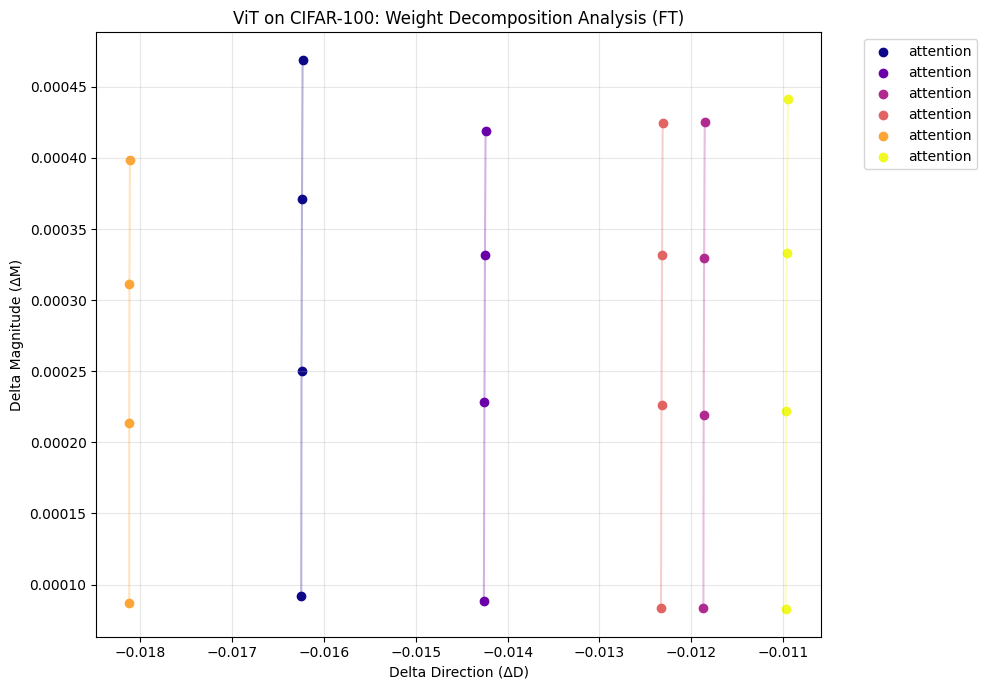

In [31]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224", 
    num_labels=100, 
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


target_layers = []
query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, nn.Linear):
        query_layers.append((name, module))
target_layers = query_layers[6:]

W0_dict = {name: mod.weight.detach().clone() for name, mod in target_layers}
history = {name: {"dm": [], "dd": []} for name, _ in target_layers}

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print(f"Training on {len(target_layers)} layers for 4 epochs...")
for epoch in range(4):
    model.train()
    epoch_loss = 0
    for step, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(pixel_values)
        loss = criterion(outputs.logits, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        
        # Capture trajectory every 100 steps
        if step % 100 == 0:
            for name, mod in target_layers:
                dm, dd = decompose(W0_dict[name], mod.weight.detach())
                history[name]["dm"].append(dm)
                history[name]["dd"].append(dd)
    print(f"Epoch {epoch+1} complete. Avg Loss: {epoch_loss/len(train_loader):.4f}")

plt.figure(figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0, 1, len(target_layers)))

for i, (name, data) in enumerate(history.items()):
    plt.plot(data["dd"], data["dm"], color=colors[i], alpha=0.3)
    plt.scatter(data["dd"], data["dm"], color=colors[i], label=name.split('.')[-2])

plt.xlabel("Delta Direction (ΔD)")
plt.ylabel("Delta Magnitude (ΔM)")
plt.title("ViT on CIFAR-100: Weight Decomposition Analysis (FT)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vit_cifar_analysis.png")

In [32]:
class LoRALinear(nn.Module):
    def __init__(self, linear_layer, r=8, alpha=16):
        super().__init__()
        self.linear = linear_layer
        self.r = r
        self.alpha = alpha
        
        in_dim = linear_layer.in_features
        out_dim = linear_layer.out_features

        self.linear.weight.requires_grad = False
        self.A = nn.Parameter(torch.randn(r, in_dim) * 0.01)
        self.B = nn.Parameter(torch.zeros(out_dim, r))

        self.scaling = alpha / r

    def forward(self, x):
        original = self.linear(x)
        lora_update = (x @ self.A.T) @ self.B.T
        return original + self.scaling * lora_update
    
class DoraLayer(nn.Module):
    def __init__(self, linear_layer, r=8, alpha=16):
        super().__init__()
        self.base_layer = linear_layer
        out_features, in_features = linear_layer.weight.shape

        self.lora_A = nn.Linear(in_features, r, bias=False)
        self.lora_B = nn.Linear(r, out_features, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        self.scaling = alpha / r

        with torch.no_grad():
            m = torch.linalg.norm(self.base_layer.weight, dim=1, keepdim=True)
        self.m = nn.Parameter(m)

    def forward(self, x):
        delta_v = (self.lora_B.weight @ self.lora_A.weight) * self.scaling
        v_new = self.base_layer.weight + delta_v
        norm_scale = self.m / torch.linalg.norm(v_new, dim=1, keepdim=True).detach()
        base_output = nn.functional.linear(x, self.base_layer.weight)
        lora_output = self.lora_B(self.lora_A(x)) * self.scaling
        result = norm_scale.view(1,1,-1) * (base_output + lora_output)
        if self.base_layer.bias is not None:
            result += self.base_layer.bias
        return result
    
def inject_lora_bert(model, r=8, alpha=16, target_modules=["query", "value"]):
    for param in model.parameters():
        param.requires_grad = False
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any(key in name for key in target_modules):
                parent_name, _, child_name = name.rpartition(".")
                parent = model.get_submodule(parent_name)
                setattr(parent, child_name, LoRALinear(module, r=r, alpha=alpha)
                )
    return model

def inject_dora_bert(model, r=8, alpha=16, target_modules=["query", "value"]):
    for param in model.parameters():
        param.requires_grad = False
    for name, module in list(model.named_modules()):
        if isinstance(module, nn.Linear):
            if any(key in name for key in target_modules):
                parent_name, _, child_name = name.rpartition(".")
                parent = model.get_submodule(parent_name)
                setattr(parent, child_name, DoraLayer(module, r=r, alpha=alpha))
    return model

In [33]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224", 
    num_labels=100, 
    ignore_mismatched_sizes=True
)
model = inject_lora_bert(model)
model.to(device)


target_layers = []
query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, (DoraLayer, LoRALinear)):
        query_layers.append((name, module))
target_layers = query_layers[6:]

W0_dict = {}
for name, layer in target_layers:
    if isinstance(layer, LoRALinear):
        W0_dict[name] = layer.linear.weight.detach().clone()
    elif isinstance(layer, DoraLayer):
        W0_dict[name] = layer.base_layer.weight.detach().clone()
    else:
        W0_dict[name] = layer.weight.detach().clone()
history = {name: {"dm": [], "dd": []} for name, _ in target_layers}

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(f"Training on {len(target_layers)} layers for 4 epochs...")
for epoch in range(4):
    model.train()
    epoch_loss = 0
    for step, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(pixel_values)
        loss = criterion(outputs.logits, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        
        # Capture trajectory every 100 steps
        if step % 100 == 0:
            for name, mod in target_layers:
                W_eff = mod.linear.weight + (mod.scaling * mod.B @ mod.A)
                dm, dd = decompose(W0_dict[name], W_eff.detach())
                
                history[name]["dm"].append(dm)
                history[name]["dd"].append(dd)
    print(f"Epoch {epoch+1} complete. Avg Loss: {epoch_loss/len(train_loader):.4f}")

plt.figure(figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0, 1, len(target_layers)))

for i, (name, data) in enumerate(history.items()):
    plt.plot(data["dd"], data["dm"], color=colors[i], alpha=0.3)
    plt.scatter(data["dd"], data["dm"], color=colors[i], label=name.split('.')[-2])

plt.xlabel("Delta Direction (ΔD)")
plt.ylabel("Delta Magnitude (ΔM)")
plt.title("ViT on CIFAR-100: Weight Decomposition Analysis (FT)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vit_cifar_analysis.png")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training on 6 layers for 4 epochs...


KeyboardInterrupt: 

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([100, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training on 6 layers for 4 epochs...
Epoch 1 complete. Avg Loss: 4.6948
Epoch 2 complete. Avg Loss: 4.5610
Epoch 3 complete. Avg Loss: 4.3686
Epoch 4 complete. Avg Loss: 4.0754


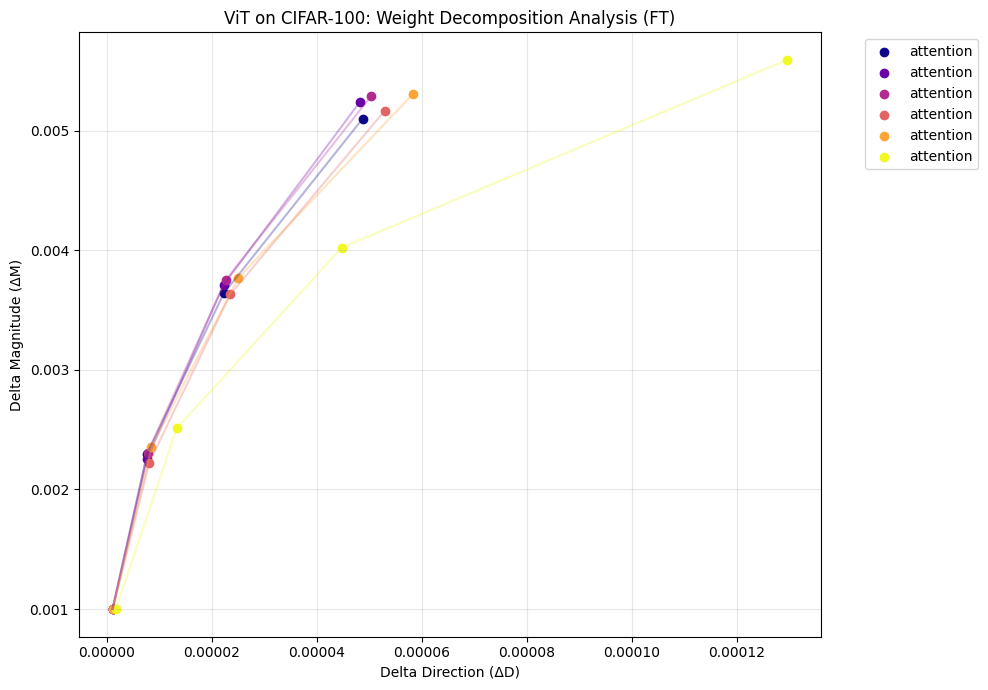

In [ ]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224", 
    num_labels=100, 
    ignore_mismatched_sizes=True
)
model = inject_dora_bert(model)
model.to(device)


target_layers = []
query_layers = []
for name, module in model.named_modules():
    if "query" in name and isinstance(module, (DoraLayer, LoRALinear)):
        query_layers.append((name, module))
target_layers = query_layers[6:]

W0_dict = {}
for name, layer in target_layers:
    if isinstance(layer, LoRALinear):
        W0_dict[name] = layer.linear.weight.detach().clone()
    elif isinstance(layer, DoraLayer):
        W0_dict[name] = layer.base_layer.weight.detach().clone()
    else:
        W0_dict[name] = layer.weight.detach().clone()
history = {name: {"dm": [], "dd": []} for name, _ in target_layers}

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(f"Training on {len(target_layers)} layers for 4 epochs...")
for epoch in range(4):
    model.train()
    epoch_loss = 0
    for step, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(pixel_values)
        loss = criterion(outputs.logits, labels)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        
        # Capture trajectory every 100 steps
        if step % 100 == 0:
            for name, mod in target_layers:
                delta_v = (mod.lora_B.weight @ mod.lora_A.weight) * mod.scaling
                v_new = mod.base_layer.weight + delta_v
                v_norm = torch.linalg.norm(v_new, dim=1, keepdim=True)
                W_eff = mod.m * (v_new / (v_norm + 1e-8))
                dm, dd = decompose(W0_dict[name], W_eff.detach())
                
                history[name]["dm"].append(dm)
                history[name]["dd"].append(dd)
    print(f"Epoch {epoch+1} complete. Avg Loss: {epoch_loss/len(train_loader):.4f}")

plt.figure(figsize=(10, 7))
colors = plt.cm.plasma(np.linspace(0, 1, len(target_layers)))

for i, (name, data) in enumerate(history.items()):
    plt.plot(data["dd"], data["dm"], color=colors[i], alpha=0.3)
    plt.scatter(data["dd"], data["dm"], color=colors[i], label=name.split('.')[-2])

plt.xlabel("Delta Direction (ΔD)")
plt.ylabel("Delta Magnitude (ΔM)")
plt.title("ViT on CIFAR-100: Weight Decomposition Analysis (FT)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vit_cifar_analysis.png")